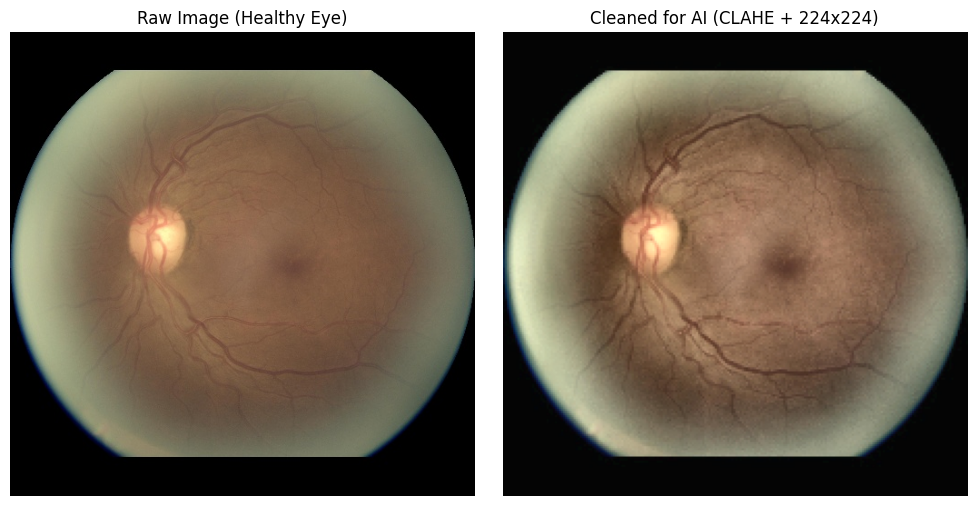

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Your exact Windows file path
IMAGE_PATH = r"C:\Users\navan\Desktop\Sem-Project\backend\eyepac-light-v2-512-jpg"

def test_cleaning(path):
    # 1. Load the raw image
    img = cv2.imread(path)
    if img is None:
        print("Error: OpenCV could not find the image. Double-check the path!")
        return

    # 2. Resize to PyTorch ResNet18 dimensions (224x224)
    resized = cv2.resize(img, (224, 224))

    # 3. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    lab = cv2.cvtColor(resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_processed = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)

    # 4. Convert colors for Matplotlib (BGR to RGB)
    original_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    processed_rgb = cv2.cvtColor(final_processed, cv2.COLOR_BGR2RGB)

    # 5. Display Side-by-Side
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Raw Image (Healthy Eye)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(processed_rgb)
    plt.title("Cleaned for AI (CLAHE + 224x224)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Execute the function
test_cleaning(IMAGE_PATH)